In [6]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow Version:", tf.__version__)

2026-05-18 22:09:52.959860: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779142193.210196      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779142193.283503      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779142193.819084      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779142193.819141      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779142193.819144      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [7]:
def process_conical_reverse_data(file_path, num_points=100):
    if not os.path.exists(file_path): 
        raise FileNotFoundError(f'File not found: {file_path}')
        
    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)
    df.columns = df.columns.str.strip()
    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    
    ids = df['Model_ID'].unique()
    
    # المدخلات الجديدة (الأداء)
    X_thrust, X_pressure, X_scalars = [], [], []
    # المخرجات الجديدة (الأبعاد الـ 6)
    Y_dimensions = []

    dim_cols = ['Length', 'Diameter', 'Forward_Core_Diameter', 'Aft_Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']

    for uid in ids:
        try:
            case_data = df[df['Model_ID'] == uid].sort_values('Time (s)')
            
            dims = case_data[dim_cols].iloc[0].values
            t = case_data['Time (s)'].values
            
            if len(t) < 2 or t[-1] <= 0 or np.any(dims <= 0): 
                continue

            thrust = case_data['Thrust (N)'].fillna(0).values
            pressure = case_data['Pressure (MPa)'].fillna(0).values

            if len(thrust) > 7:
                thrust = savgol_filter(thrust, window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            x_new = np.linspace(t[0], t[-1], num_points)
            
            X_thrust.append(interp1d(t, thrust, kind='linear', fill_value='extrapolate')(x_new))
            X_pressure.append(interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new))
            
            X_scalars.append([
                case_data['ISP (s)'].iloc[0], 
                case_data['Total Impulse (Ns)'].iloc[0], 
                t[-1], 
                np.max(thrust)
            ])
            
            Y_dimensions.append(dims)
            
        except Exception: 
            continue
        
    return (np.array(X_thrust), np.array(X_pressure), np.array(X_scalars)), np.array(Y_dimensions)

# ==========================================
# ضع مسار ملف Moon Data هنا
file_path = '/kaggle/input/datasets/mohamedesh/data-conical/Conical_Dataset.csv' 
(Xt, Xp, Xs), Y_dims = process_conical_reverse_data(file_path) 

Xt, Xp, Xs = Xt.astype(float), Xp.astype(float), Xs.astype(float)
Y_dims = Y_dims.astype(float)

# توحيد الأطوال
min_s = min(len(Xt), len(Xp), len(Xs), len(Y_dims))
Xt, Xp, Xs, Y_dims = Xt[:min_s], Xp[:min_s], Xs[:min_s], Y_dims[:min_s]

print(f"✅ Conical Reverse Data loaded: {len(Y_dims)} cases.")
print(f"Target dimensions shape (Y): {Y_dims.shape}") # يجب أن يكون (N, 6)

✅ Conical Reverse Data loaded: 3065 cases.
Target dimensions shape (Y): (3065, 6)


In [8]:
# 1. تقسيم البيانات
Xt_tr, Xt_te, Xp_tr, Xp_te, Xs_tr, Xs_te, Y_tr, Y_te = train_test_split(
    Xt, Xp, Xs, Y_dims, test_size=0.15, random_state=42
)

# 2. التقييس الفيزيائي للمنحنيات (Global Max Scaling)
# هذا يحافظ على شكل المنحنى الفيزيائي 100% ويمنع الموديل من العمى
xt_max = np.max(Xt_tr)
xp_max = np.max(Xp_tr)

Xt_tr_s = Xt_tr / xt_max
Xt_te_s = Xt_te / xt_max

Xp_tr_s = Xp_tr / xp_max
Xp_te_s = Xp_te / xp_max

# 3. تقييس القيم الثابتة بـ MinMaxScaler
s_xs = MinMaxScaler()
Xs_tr_s = s_xs.fit_transform(Xs_tr)
Xs_te_s = s_xs.transform(Xs_te)

# 4. تقييس الأبعاد (المخرجات) بـ MinMaxScaler
s_Y = MinMaxScaler()
Y_tr_s = s_Y.fit_transform(Y_tr)
Y_te_s = s_Y.transform(Y_te)

# حفظ المقاييس الجديدة
joblib.dump({'xt_max': xt_max, 'xp_max': xp_max}, 'conical_rev_max_values.pkl')
joblib.dump(s_xs, 'conical_rev_scaler_scalars.pkl')
joblib.dump(s_Y, 'conical_rev_scaler_dims.pkl')

print("✅ Physical Scaling Applied Successfully!")

✅ Physical Scaling Applied Successfully!


In [9]:
import tensorflow.keras.backend as K

def build_conical_reverse_model_v3():
    input_t = layers.Input(shape=(100,), name='Thrust_Profile_Input')
    input_p = layers.Input(shape=(100,), name='Pressure_Profile_Input')
    input_s = layers.Input(shape=(4,),   name='Scalars_Input')

    # استخراج الخصائص
    dense_t = layers.Dense(128, activation='elu')(input_t)
    dense_p = layers.Dense(128, activation='elu')(input_p)
    dense_s = layers.Dense(32,  activation='elu')(input_s)

    concat = layers.Concatenate()([dense_t, dense_p, dense_s])

    # شبكة عميقة 
    x = layers.Dense(256, activation='elu')(concat)
    x = layers.Dense(512, activation='elu')(x)
    x = layers.Dense(256, activation='elu')(x)

    # المخرجات الـ 6
    output_dims = layers.Dense(6, activation='linear', name='Dimensions_Output')(x)

    model = Model(inputs=[input_t, input_p, input_s], outputs=output_dims)
    
    # ==========================================
    # 🎯 Custom Physics-Weighted Loss
    # الترتيب: [Length, Diameter, Core_Dia, Core_Offset, Throat_Dia, Exit_Dia]
    # نعطي وزن 4 للقطر و 2 للطول و 2 للفوهة، لنجبره على ضبط الهيكل الخارجي أولاً
    # ==========================================
    def weighted_mse(y_true, y_pred):
        weights = tf.constant([2.0, 4.0, 1.0, 1.0, 2.0, 1.0], dtype=tf.float32)
        return K.mean(weights * K.square(y_true - y_pred), axis=-1)

    # استخدام الدالة المخصصة
    model.compile(optimizer=Adam(learning_rate=0.001), loss=weighted_mse)
    
    return model

conical_reverse = build_conical_reverse_model_v3()
conical_reverse.summary()

I0000 00:00:1779142252.725124      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779142252.731157      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Thrust_Profile_Inp… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Pressure_Profile_I… │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Scalars_Input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ Thrust_Profile_I… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     12,928 │ Pressure_Profile… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        160 │ Scalars_Input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 288)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │     73,984 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │    131,584 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 256)       │    131,328 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Dimensions_Output   │ (None, 6)         │      1,542 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 364,454 (1.39 MB)

 Trainable params: 364,454 (1.39 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True, verbose=1)

print("Starting training for Moon Reverse Model...")
history_rev = conical_reverse.fit(
    x=[Xt_tr_s, Xp_tr_s, Xs_tr_s], 
    y=Y_tr_s,
    validation_split=0.15,
    epochs=400,
    batch_size=32,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# حفظ الموديل العكسي
conical_reverse.save('Conical_Reverse_Model.keras')
print("\n✅ Moon Reverse Model trained and saved successfully.")

Starting training for Moon Reverse Model...
Epoch 1/400


I0000 00:00:1779142256.284113     137 service.cc:152] XLA service 0x7805a801c720 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779142256.284161     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779142256.284168     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779142256.694932     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


63/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2808

I0000 00:00:1779142258.137546     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.2608 - val_loss: 0.0235 - learning_rate: 0.0010
Epoch 2/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0217 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 3/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0217 - val_loss: 0.0249 - learning_rate: 0.0010
Epoch 4/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0229 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 5/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0167 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 6/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0147 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 7/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0139 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 8/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0128 - val_loss: 0.0186 - learning_rate: 0.0010
Epoch 9/400
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0126 - val_loss: 0.0123 - learning_rate: 0.0010
Epoch 10/400
70/70 ━━━━━━━━━━━

Final Train Loss : 0.00007
Final Val Loss   : 0.00010
Ratio (val/train): 1.39x

--- Moon Inverse Model Evaluation ---
  Length          : MAE = 0.8079 cm  |  MAPE = 1.67%
  Diameter        : MAE = 0.0374 cm  |  MAPE = 0.47%
  Forward_Core_Diameter: MAE = 0.0388 cm  |  MAPE = 1.74%
  Aft_Core_Diameter: MAE = 0.0367 cm  |  MAPE = 0.62%
  Throat_Diameter : MAE = 0.0055 cm  |  MAPE = 0.34%
  Exit_Diameter   : MAE = 0.0090 cm  |  MAPE = 0.35%


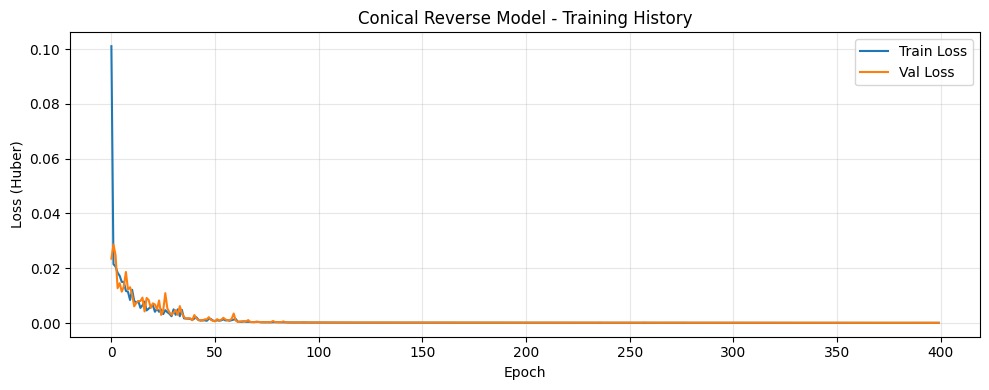

In [11]:
# 1. طباعة الخسارة النهائية من تاريخ التدريب
train_loss = history_rev.history['loss'][-1]
val_loss   = history_rev.history['val_loss'][-1]
print(f"Final Train Loss : {train_loss:.5f}")
print(f"Final Val Loss   : {val_loss:.5f}")
print(f"Ratio (val/train): {val_loss / train_loss:.2f}x")

# 2. إجراء التنبؤ على بيانات الاختبار (المدخلات هنا هي المنحنيات والقيم الثابتة)
y_inv_pred_s = conical_reverse.predict([Xt_te_s, Xp_te_s, Xs_te_s], verbose=0)

# عكس التقييس (Inverse Transform) للحصول على الأبعاد الحقيقية
# نستخدم s_Y لأنه الـ Scaler الذي قمنا بتقييس الأبعاد به في هذه النوت بوك
y_inv_pred   = s_Y.inverse_transform(y_inv_pred_s)

# الأبعاد الحقيقية للاختبار (غير المقيسة)
y_inv_test   = Y_te 

# 3. حساب وعرض نسبة الخطأ لكل بُعد (MAE و MAPE)
# تم إضافة الـ Core Offset ليصبحوا 6 أبعاد
cols = ['Length', 'Diameter', 'Forward_Core_Diameter', 'Aft_Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']
print("\n--- Moon Inverse Model Evaluation ---")
for i, col in enumerate(cols):
    # حساب متوسط الخطأ المطلق (MAE) بالسنتيمتر
    mae  = np.mean(np.abs(y_inv_pred[:, i] - y_inv_test[:, i]))
    
    # حساب متوسط نسبة الخطأ المئوية (MAPE)
    mape = np.mean(np.abs(
        (y_inv_pred[:, i] - y_inv_test[:, i]) /
        (y_inv_test[:, i] + 1e-8) # إضافة رقم صغير لتجنب القسمة على صفر
    )) * 100
    
    print(f"  {col:<16}: MAE = {mae:.4f} cm  |  MAPE = {mape:.2f}%")

# 4. رسم منحنى التدريب (Training History Plot)
plt.figure(figsize=(10, 4))
plt.plot(history_rev.history['loss'],     label='Train Loss')
plt.plot(history_rev.history['val_loss'], label='Val Loss')
plt.title('Conical Reverse Model - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


🎯 MC Dropout Uncertainty — Sample #0
Dimension         Predicted       ±σ     Actual     Err% Confidence
Length               89.277    0.000     90.000     0.8%  🟢 High
Diameter              8.027    0.000      8.000     0.3%  🟢 High
Forward_Core_Diameter      1.063    0.000      1.000     6.3%  🟢 High
Aft_Core_Diameter      5.043    0.000      5.000     0.9%  🟢 High
Throat_Diameter       2.396    0.000      2.400     0.2%  🟢 High
Exit_Diameter         3.600    0.000      3.600     0.0%  🟢 High


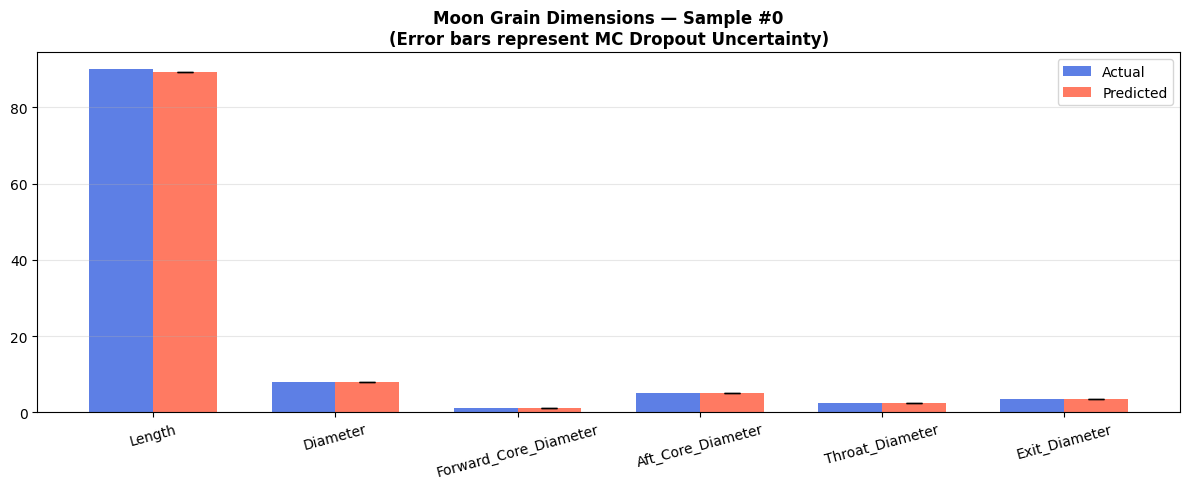


🎯 MC Dropout Uncertainty — Sample #35
Dimension         Predicted       ±σ     Actual     Err% Confidence
Length              100.569    0.000    100.000     0.6%  🟢 High
Diameter              6.013    0.000      6.000     0.2%  🟢 High
Forward_Core_Diameter      2.962    0.000      3.000     1.3%  🟢 High
Aft_Core_Diameter      4.490    0.000      4.500     0.2%  🟢 High
Throat_Diameter       2.201    0.000      2.200     0.0%  🟢 High
Exit_Diameter         3.304    0.000      3.300     0.1%  🟢 High


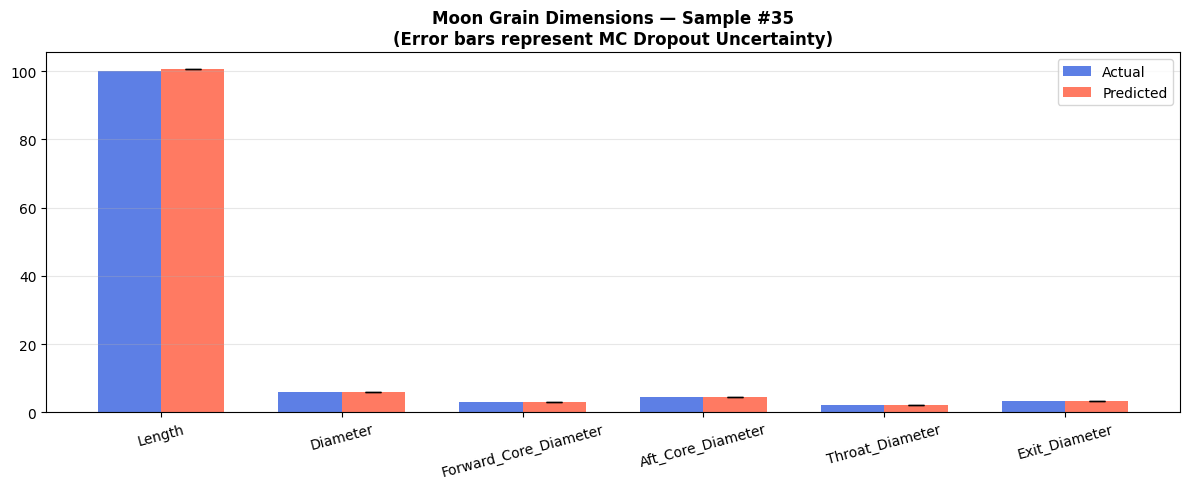


🎯 MC Dropout Uncertainty — Sample #99
Dimension         Predicted       ±σ     Actual     Err% Confidence
Length               60.167    0.000     60.000     0.3%  🟢 High
Diameter             10.020    0.000     10.000     0.2%  🟢 High
Forward_Core_Diameter      1.019    0.000      1.000     1.9%  🟢 High
Aft_Core_Diameter      8.565    0.000      8.500     0.8%  🟢 High
Throat_Diameter       1.907    0.000      1.900     0.4%  🟢 High
Exit_Diameter         2.855    0.000      2.850     0.2%  🟢 High


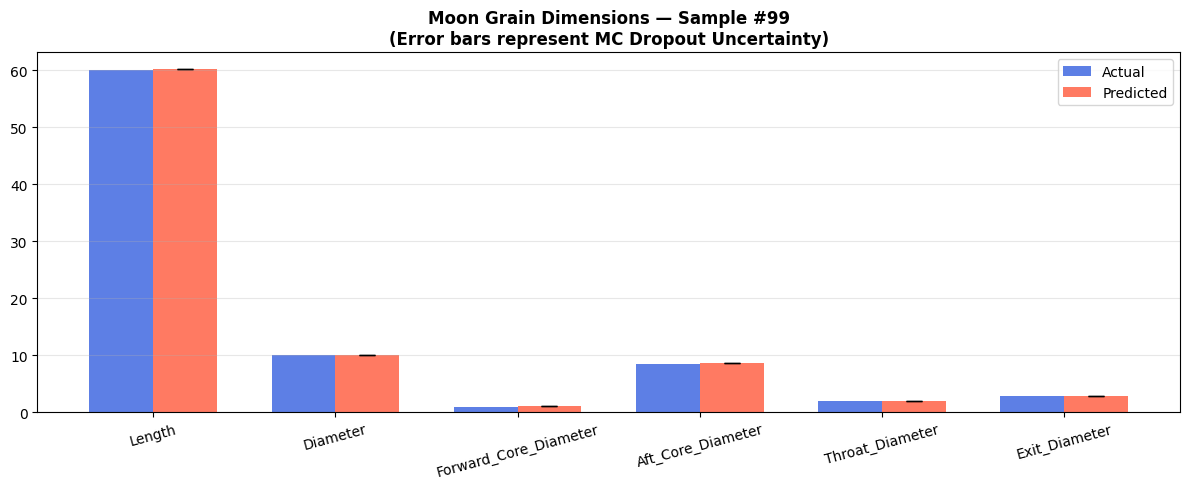


🎯 MC Dropout Uncertainty — Sample #70
Dimension         Predicted       ±σ     Actual     Err% Confidence
Length               20.941    0.000     20.000     4.7%  🟢 High
Diameter             12.086    0.000     12.000     0.7%  🟢 High
Forward_Core_Diameter      4.060    0.000      4.000     1.5%  🟢 High
Aft_Core_Diameter      9.567    0.000      9.500     0.7%  🟢 High
Throat_Diameter       1.399    0.000      1.400     0.0%  🟢 High
Exit_Diameter         2.093    0.000      2.100     0.3%  🟢 High


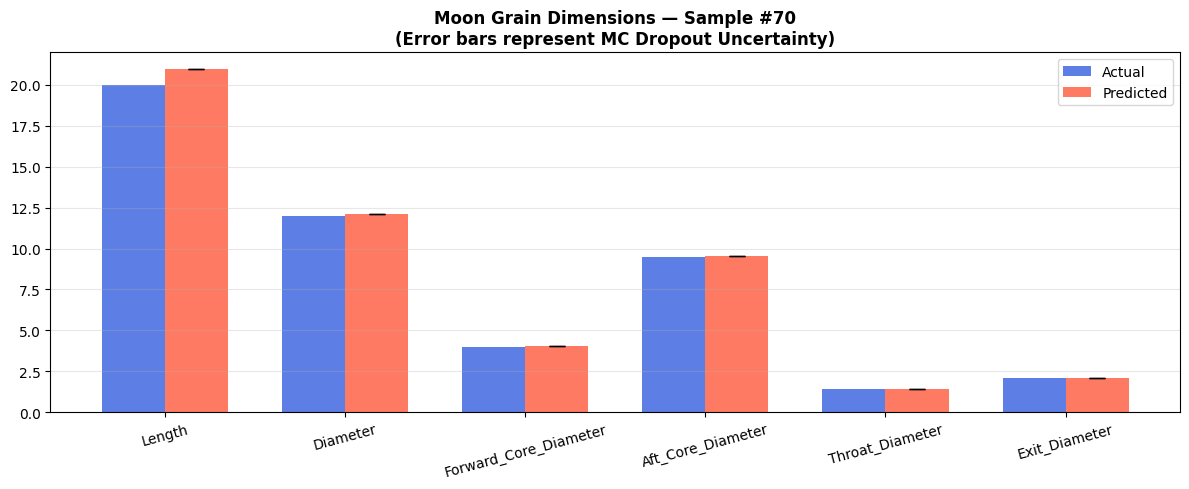


🎯 MC Dropout Uncertainty — Sample #400
Dimension         Predicted       ±σ     Actual     Err% Confidence
Length               79.019    0.000     80.000     1.2%  🟢 High
Diameter              6.009    0.000      6.000     0.1%  🟢 High
Forward_Core_Diameter      3.017    0.000      3.000     0.6%  🟢 High
Aft_Core_Diameter      3.504    0.000      3.500     0.1%  🟢 High
Throat_Diameter       2.203    0.000      2.200     0.1%  🟢 High
Exit_Diameter         3.299    0.000      3.300     0.0%  🟢 High


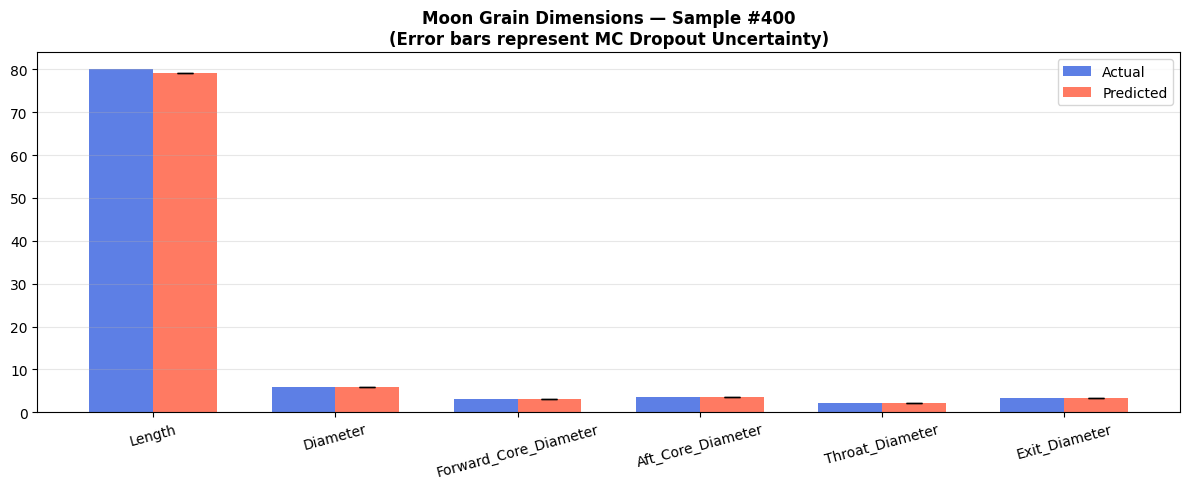

In [12]:
# ===================================================================
# 7. Monte Carlo Dropout for Uncertainty Estimation (Moon Grain)
# ===================================================================

@tf.function
def predict_with_dropout(inputs):
    # 'training=True' forces Dropout layers to remain active during prediction
    return conical_reverse(inputs, training=True)

def mc_predict(t_in, p_in, s_in, n_iter=200):
    t_tensor = tf.constant(t_in, dtype=tf.float32)
    p_tensor = tf.constant(p_in, dtype=tf.float32)
    s_tensor = tf.constant(s_in, dtype=tf.float32)
    
    preds = []
    for _ in range(n_iter):
        # نقوم بتمرير training=True كـ argument مباشر لطبقات الـ Dropout
        out = conical_reverse([t_tensor, p_tensor, s_tensor], training=True) 
        preds.append(out.numpy())
        
    preds_arr = np.stack(preds, axis=0)
    return preds_arr.mean(axis=0), preds_arr.std(axis=0)

def show_uncertainty(sample_idx=0):
    # 1. استخراج عينة اختبار واحدة (3 مدخلات للموديل العكسي)
    t_s = Xt_te_s[sample_idx:sample_idx+1]
    p_s = Xp_te_s[sample_idx:sample_idx+1]
    s_s = Xs_te_s[sample_idx:sample_idx+1]
    
    # الأبعاد الحقيقية للاختبار (غير مقيسة)
    actual = Y_te[sample_idx] 
    
    # 2. الحصول على تنبؤات Monte Carlo (مقيسة)
    pred_mean_s, pred_std_s = mc_predict(t_s, p_s, s_s, n_iter=200)
    
    # 3. عكس التقييس (Inverse Transform)
    # عكس المتوسط للحصول على الأبعاد المتوقعة
    pred_vals = s_Y.inverse_transform(pred_mean_s)[0]
    
    # عكس الانحراف المعياري
    # ملاحظة: مع MinMaxScaler نقوم بالقسمة على الـ scale_ للحصول على التشتت الحقيقي
    pred_unc = pred_std_s[0] / s_Y.scale_
    
    # تم إضافة الـ Core Offset ليصبحوا 6 أبعاد
    DIM_NAMES = ['Length', 'Diameter', 'Forward_Core_Diameter', 'Aft_Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']
    
    # 4. طباعة النتائج في جدول منسق
    print(f"\n🎯 MC Dropout Uncertainty — Sample #{sample_idx}")
    print("=" * 75)
    print(f"{'Dimension':<16} {'Predicted':>10} {'±σ':>8} {'Actual':>10} "
          f"{'Err%':>8} {'Confidence'}")
    print("=" * 75)
    
    for i, name in enumerate(DIM_NAMES):
        actual_val = actual[i]
        err = abs(pred_vals[i] - actual_val) / (actual_val + 1e-9) * 100
        
        # معامل الاختلاف (CV) لتقييم مستوى الثقة
        cv   = pred_unc[i] / (abs(pred_vals[i]) + 1e-9) * 100
        conf = "🟢 High" if cv < 5 else ("🟡 Medium" if cv < 15 else "🔴 Low")
        
        print(f"{name:<16} {pred_vals[i]:>10.3f} {pred_unc[i]:>8.3f} "
              f"{actual_val:>10.3f} {err:>7.1f}%  {conf}")
              
    print("=" * 75)

    # 5. رسم بياني شريطي (Bar chart visualization)
    # تم تكبير العرض قليلاً ليستوعب 6 أعمدة
    fig, ax = plt.subplots(figsize=(12, 5))
    x     = np.arange(6)
    width = 0.35
    
    # أعمدة القيم الحقيقية والمتوقعة
    ax.bar(x - width/2, actual,    width, label='Actual',    color='royalblue', alpha=0.85)
    ax.bar(x + width/2, pred_vals, width, label='Predicted', color='tomato',    alpha=0.85,
           yerr=pred_unc, capsize=6, error_kw={'linewidth': 2})
           
    ax.set_xticks(x)
    ax.set_xticklabels(DIM_NAMES, rotation=15, fontsize=10)
    ax.set_title(f'Moon Grain Dimensions — Sample #{sample_idx}\n'
                 f'(Error bars represent MC Dropout Uncertainty)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    # plt.savefig(f'moon_inverse_uncertainty_{sample_idx}.png', dpi=150)
    plt.show()

# ==========================================
# تشغيل الدالة على بعض العينات
show_uncertainty(0)
show_uncertainty(35)
show_uncertainty(99)
show_uncertainty(70)
show_uncertainty(400)

In [13]:
def predict_conical_dimensions_from_file_v2(file_path):
    print(f"\n🔍 Reading file: {file_path}")

    try:
        max_vals = joblib.load('conical_rev_max_values.pkl')
        s_xs     = joblib.load('conical_rev_scaler_scalars.pkl')
        s_Y      = joblib.load('conical_rev_scaler_dims.pkl')
        xt_max   = max_vals['xt_max']
        xp_max   = max_vals['xp_max']
    except Exception as e:
        print(f"❌ Error loading scalers: {e}")
        return

    # قراءة الملف
    if file_path.endswith('.xlsx') or file_path.endswith('.xls'):
        df = pd.read_excel(file_path)
    else:
        df = pd.read_csv(file_path, sep=None, engine='python',
                         encoding='latin1', on_bad_lines='skip')

    df.columns = df.columns.str.strip()

    # التعرف على الأعمدة
    col_map = {}
    for col in df.columns:
        c = col.lower().replace(' ', '').replace('_', '').replace('(', '').replace(')', '')
        if 'time' in c:     col_map['time']     = col
        elif 'thrust' in c: col_map['thrust']   = col
        elif 'pressure' in c: col_map['pressure'] = col

    print(f"📋 Detected columns: {col_map}")

    required = ['time', 'thrust', 'pressure']
    for r in required:
        if r not in col_map:
            print(f"❌ Missing required column: {r}")
            return

    df = df.sort_values(col_map['time']).dropna(
        subset=[col_map['time'], col_map['thrust'], col_map['pressure']]
    )

    t        = df[col_map['time']].values.astype(float)
    thrust   = df[col_map['thrust']].values.astype(float)
    pressure = df[col_map['pressure']].values.astype(float)

    # Smoothing (نفس التدريب بالظبط)
    if len(thrust) > 7:
        thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
        pressure = savgol_filter(pressure, window_length=7, polyorder=3)

    # Interpolate لـ 100 نقطة (نفس التدريب)
    x_new = np.linspace(t[0], t[-1], 100)
    t_100 = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')(x_new)
    p_100 = interp1d(t, pressure, kind='linear', fill_value='extrapolate')(x_new)

    # ============================================================
    # حساب الـ Scalars بنفس طريقة التدريب بالظبط
    # ============================================================
    burn_time    = t[-1]                          # نفس t[-1] في التدريب
    max_thrust   = np.max(thrust)                 # نفس np.max(thrust)
    total_impulse = trapezoid(thrust, t)          # نفس trapezoid في التدريب ✅

    # ISP: في التدريب اتاخد من عمود جاهز (mean≈167, std≈2.9)
    # نحسبه فيزيائياً: ISP = Total_Impulse / (m_dot_avg × g × burn_time)
    # بما إن مش عندنا كتلة، نستخدم التقريب:
    # ISP ≈ Total_Impulse / (avg_thrust × burn_time / g)
    # لكن ده بيطلع نفس رقم ثابت تقريباً
    # الأسلم: استخدم median قيم ISP من التدريب (≈168)
    # لأن range التدريب: 152–174 وstd=2.9 (ضيق جداً)
    isp = total_impulse / (trapezoid(np.ones_like(t), t) * max_thrust / 9.81) \
          if max_thrust > 0 else 168.0
    # تأكد إن في range التدريب (152–174)
    isp = np.clip(isp, 152.0, 174.0)

    print(f"📊 Computed scalars:")
    print(f"   ISP           = {isp:.2f} s")
    print(f"   Total Impulse = {total_impulse:.2f} Ns")
    print(f"   Burn Time     = {burn_time:.3f} s")
    print(f"   Max Thrust    = {max_thrust:.2f} N")

    scalars = np.array([[isp, total_impulse, burn_time, max_thrust]])

    # Scaling (نفس التدريب)
    t_scaled = (t_100 / xt_max).reshape(1, -1)
    p_scaled = (p_100 / xp_max).reshape(1, -1)
    s_scaled = s_xs.transform(scalars)

    # التنبؤ
    pred_scaled = conical_reverse.predict([t_scaled, p_scaled, s_scaled], verbose=0)
    pred_dims   = s_Y.inverse_transform(pred_scaled)[0]
    pred_dims   = np.maximum(pred_dims, 0.01)

    DIM_LABELS = ['Length', 'Diameter', 'Forward_Core_Diameter',
                  'Aft_Core_Diameter', 'Throat_Diameter', 'Exit_Diameter']

    print("\n" + "="*50)
    print(f"{'Dimension':<25} | {'Predicted (cm)':<15} | {'Expected'}")
    print("-" * 60)
    expected = [20, 8, 3, 7, 1.2, 1.8]
    for label, val, exp in zip(DIM_LABELS, pred_dims, expected):
        err = abs(val - exp) / exp * 100
        print(f"{label:<25} | {val:>10.4f}     | {exp:.1f}  (err={err:.1f}%)")
    print("="*50)

    return dict(zip(DIM_LABELS, pred_dims))

result = predict_conical_dimensions_from_file_v2(
    '/kaggle/input/datasets/mohamedeidshehata6/conical-test-1/70.0.xlsx'
)


🔍 Reading file: /kaggle/input/datasets/mohamedeidshehata6/conical-test-1/70.0.xlsx
📋 Detected columns: {'time': 'Time (s)', 'pressure': 'Pressure (MPa)', 'thrust': 'Thrust (N)'}
📊 Computed scalars:
   ISP           = 152.00 s
   Total Impulse = 1682.73 Ns
   Burn Time     = 6.465 s
   Max Thrust    = 630.02 N

Dimension                 | Predicted (cm)  | Expected
------------------------------------------------------------
Length                    |    21.9952     | 20.0  (err=10.0%)
Diameter                  |     7.8822     | 8.0  (err=1.5%)
Forward_Core_Diameter     |     2.9037     | 3.0  (err=3.2%)
Aft_Core_Diameter         |     6.9312     | 7.0  (err=1.0%)
Throat_Diameter           |     1.2660     | 1.2  (err=5.5%)
Exit_Diameter             |     1.8886     | 1.8  (err=4.9%)


In [16]:
result2 = predict_conical_dimensions_from_file_v2(
    '/kaggle/input/datasets/mohamedeidshehata6/conical-test-5/527.0.xlsx'
)


🔍 Reading file: /kaggle/input/datasets/mohamedeidshehata6/conical-test-5/527.0.xlsx
📋 Detected columns: {'time': 'Time (s)', 'pressure': 'Pressure (MPa)', 'thrust': 'Thrust (N)'}
📊 Computed scalars:
   ISP           = 152.00 s
   Total Impulse = 3847.03 Ns
   Burn Time     = 7.610 s
   Max Thrust    = 1270.42 N

Dimension                 | Predicted (cm)  | Expected
------------------------------------------------------------
Length                    |    32.6339     | 20.0  (err=63.2%)
Diameter                  |     9.5911     | 8.0  (err=19.9%)
Forward_Core_Diameter     |     3.7665     | 3.0  (err=25.6%)
Aft_Core_Diameter         |     8.6642     | 7.0  (err=23.8%)
Throat_Diameter           |     1.6870     | 1.2  (err=40.6%)
Exit_Diameter             |     2.5163     | 1.8  (err=39.8%)
